In [13]:
import librosa
import numpy as np

def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=None)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfccs_scaled = np.mean(mfccs.T, axis=0)
    return mfccs_scaled

In [15]:
import os
import numpy as np
import pandas as pd
import librosa

In [17]:
real_path = "dataset/real"
fake_path = "dataset/fake"

X = []
y = []

for file in os.listdir(real_path):
    if file.endswith(".wav"):
        X.append(extract_features(os.path.join(real_path, file)))
        y.append(0)   # 0 = real

for file in os.listdir(fake_path):
    if file.endswith(".wav"):
        X.append(extract_features(os.path.join(fake_path, file)))
        y.append(1)   # 1 = fake

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (42, 13)


In [ ]:
from sklearn.model_selection import train_test_split

# Make sure X and y are numpy arrays
X = np.array(X)
y = np.array(y)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score   # ✅ add this

svm_model = make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True))
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8888888888888888


In [25]:
import joblib

joblib.dump(svm_model, "voice_detector.pkl")
print("Model saved!")

Model saved!


In [27]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# Feature extraction
def extract_features(file):
    y, sr = librosa.load(file, duration=3)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfcc.T, axis=0)

X = []
y = []

# Real voices = label 0
for file in os.listdir("dataset/real"):
    if file.endswith(".wav"):
        X.append(extract_features("dataset/real/" + file))
        y.append(0)

# Fake voices = label 1
for file in os.listdir("dataset/fake"):
    if file.endswith(".wav"):
        X.append(extract_features("dataset/fake/" + file))
        y.append(1)

X = np.array(X)
y = np.array(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "voice_detector.pkl")
print("Model trained and saved!")

Model trained and saved!


In [29]:
model = joblib.load("voice_detector.pkl")

test_file = "dataset/real/Recording (1).wav"# change file name
feat = extract_features(test_file).reshape(1, -1)

pred = model.predict(feat)[0]

if pred == 0:
    print("REAL HUMAN VOICE")
else:
    print("FAKE AI VOICE")








REAL HUMAN VOICE


In [31]:
model = joblib.load("voice_detector.pkl")

test_file = "dataset/fake/Recording (1).wav"

feat = extract_features(test_file).reshape(1, -1)

pred = model.predict(feat)[0]

if pred == 0:
    print("REAL HUMAN VOICE")
else:
    print("FAKE AI VOICE")

FAKE AI VOICE


In [33]:
import os

print("REAL FILES:")
for file in os.listdir("dataset/real"):
    print(file)

print("\nFAKE FILES:")
for file in os.listdir("dataset/fake"):
    print(file)

REAL FILES:
.ipynb_checkpoints
Recording (1).wav
Recording (10).wav
Recording (11).wav
Recording (12).wav
Recording (13).wav
Recording (14).wav
Recording (15).wav
Recording (16).wav
Recording (17).wav
Recording (18).wav
Recording (19).wav
Recording (2).wav
Recording (20).wav
Recording (21).wav
Recording (3).wav
Recording (4).wav
Recording (5).wav
Recording (6).wav
Recording (7).wav
Recording (8).wav
Recording (9).wav

FAKE FILES:
.ipynb_checkpoints
Recording (1).wav
Recording (10).wav
Recording (11).wav
Recording (12).wav
Recording (13).wav
Recording (14).wav
Recording (15).wav
Recording (16).wav
Recording (17).wav
Recording (18).wav
Recording (19).wav
Recording (2).wav
Recording (20).wav
Recording (21).wav
Recording (3).wav
Recording (4).wav
Recording (5).wav
Recording (6).wav
Recording (7).wav
Recording (8).wav
Recording (9).wav


In [35]:
X = np.array(X)
y = np.array(y)

print("Total samples:", len(X))

Total samples: 42


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 29
Test samples: 13


In [38]:
import joblib
joblib.dump(model, "voice_model.pkl")

['voice_model.pkl']

In [40]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.svm import SVC
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.83      1.00      0.91         5

    accuracy                           0.89         9
   macro avg       0.92      0.88      0.88         9
weighted avg       0.91      0.89      0.89         9



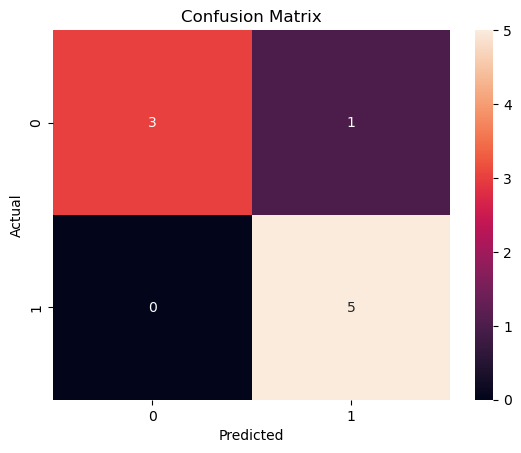

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
import joblib
joblib.dump(model, "voice_model.pkl")

['voice_model.pkl']